# Import Libraries

In [2]:
import pandas as pd
from pathlib import Path
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


# Configuring project paths and importing core modules

## 

In [12]:
BASE_DIR = Path.cwd().parents[1]
DATA_DIR = BASE_DIR / "data"
FEATURES_DIR = DATA_DIR / "dl_features"
print(BASE_DIR)
print(DATA_DIR)
print(FEATURES_DIR)

c:\Users\admin\Desktop
c:\Users\admin\Desktop\data
c:\Users\admin\Desktop\data\dl_features


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent)) 

from src.models.cnn_baseline import load_features, build_cnn_model, evaluate_model
import src.models.cnn_baseline as cnn_utils
from pathlib import Path

cnn_utils.FEATURES_DIR = Path(r"C:\Users\admin\Desktop\nlp-fake-news-detector-transformers\data\dl_features")



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hyperparameter Tuning & Experiments
To achieve the best performance, we conduct several experiments varying the following:
* **Optimizers:** Adam vs. RMSprop.
* **Dropout Rates:** 0.5 vs. 0.7 (to control overfitting).
* **Batch Sizes:** 32 vs. 64.

We use **Early Stopping** to prevent overfitting and ensure the model stops training once the validation loss stabilizes.

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test, meta = load_features()

experiments = [
    {"name": "Baseline (Adam, 0.5 DP, 32 BS)", "opt": "adam", "dr": 0.5, "bs": 32},
    {"name": "High Dropout(Adam) (Adam, 0.7 DP, 32 BS)", "opt": "adam", "dr": 0.7, "bs": 32},
    {"name": "Large Batch(Adam) (Adam, 0.5 DP, 64 BS)", "opt": "adam", "dr": 0.5, "bs": 64},

    {"name": "RMSprop (RMS, 0.5 DP, 32 BS)", "opt": "rmsprop", "dr": 0.5, "bs": 32},
    {"name": "High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)", "opt": "rmsprop", "dr": 0.7, "bs": 32},
    {"name": "Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)", "opt": "rmsprop", "dr": 0.5, "bs": 64},
]

results_list = [] 

Loading data from: C:\Users\admin\Desktop\nlp-fake-news-detector-transformers\data\dl_features


In [18]:
early_stopping = EarlyStopping(monitor = 'val_loss',
                               patience = 2,
                               restore_best_weights = True)

In [22]:
def run_experiment(exp, X_train, y_train, X_val, y_val, X_test, y_test, meta):
    model = build_cnn_model(
        max_words=meta["max_words"],
        max_len=meta["max_len"],
        dropout_rate=exp["dr"],
        optimizer=exp["opt"]
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=exp["bs"],
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_test, y_test)

    exp_results = exp.copy()
    exp_results.update(metrics)

    return exp_results

results_list = []

for exp in experiments:
    print(f"Running: {exp['name']}")

    result = run_experiment(
        exp,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        meta
    )

    results_list.append(result)

Running: Baseline (Adam, 0.5 DP, 32 BS)
Building CNN model (Optimizer: adam, Dropout: 0.5)....
Running: High Dropout(Adam) (Adam, 0.7 DP, 32 BS)
Building CNN model (Optimizer: adam, Dropout: 0.7)....
Running: Large Batch(Adam) (Adam, 0.5 DP, 64 BS)
Building CNN model (Optimizer: adam, Dropout: 0.5)....
Running: RMSprop (RMS, 0.5 DP, 32 BS)
Building CNN model (Optimizer: rmsprop, Dropout: 0.5)....
Running: High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)
Building CNN model (Optimizer: rmsprop, Dropout: 0.7)....
Running: Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)
Building CNN model (Optimizer: rmsprop, Dropout: 0.5)....


# Results & Ranking
After running all experiments, we compile the results into a table to compare performance based on **Accuracy, Precision, Recall, and F1-Score**. The experiments are ranked by their **F1-Score**.

In [ ]:
results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(by='f1', ascending=False)

print("\nFinal Experiments Ranking:")
display(results_df)




Final Experiments Ranking:


,name,opt,dr,bs,accuracy,precision,recall,f1
2,"Large Batch(Adam) (Adam, 0.5 DP, 64 BS)",adam,0.5,64,0.793363,0.781602,0.807536,0.794357
0,"Baseline (Adam, 0.5 DP, 32 BS)",adam,0.5,32,0.791467,0.780212,0.804758,0.792295
1,"High Dropout(Adam) (Adam, 0.7 DP, 32 BS)",adam,0.7,32,0.787848,0.775741,0.802819,0.789048
5,"Large Batch(RMSprop) (RMS, 0.5 DP, 64 BS)",rmsprop,0.5,64,0.781539,0.768328,0.798840,0.783287
3,"RMSprop (RMS, 0.5 DP, 32 BS)",rmsprop,0.5,32,0.778176,0.772374,0.781468,0.776894
4,"High Dropout(RMSprop) (RMS, 0.7 DP, 32 BS)",rmsprop,0.7,32,0.771935,0.763735,0.779755,0.771662


# Visualizing Performance
A graphical comparison of the F1-Score across all experiments to clearly identify the top-performing configuration.

C:\Users\admin\AppData\Local\Temp\ipykernel_17120\382017120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='f1', y='name', data=results_df, palette='magma')


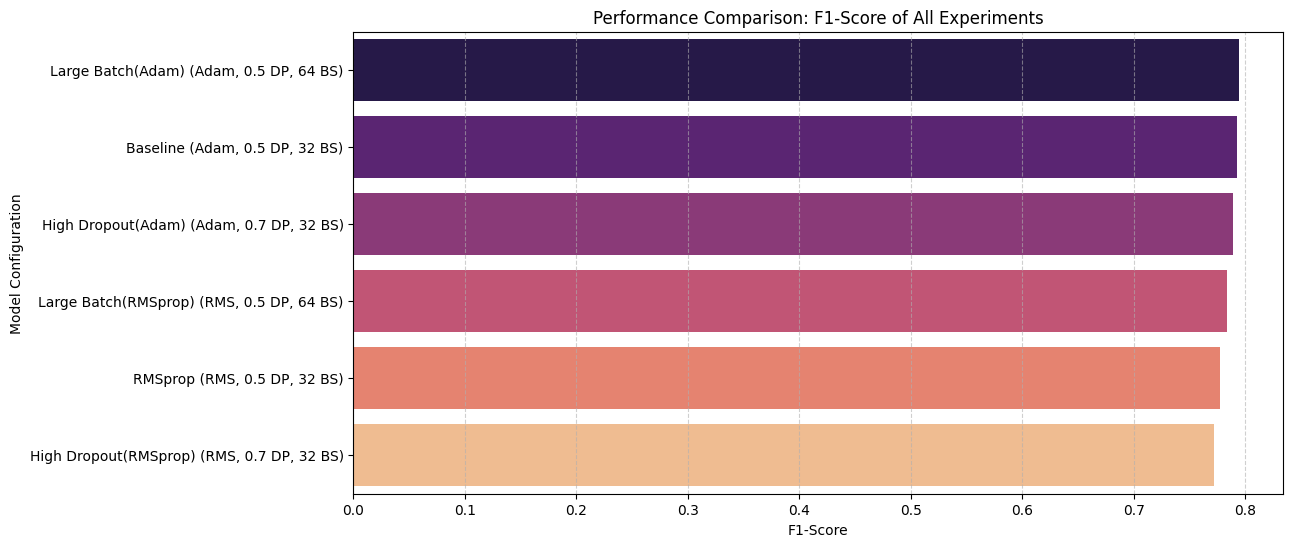

In [33]:
plt.figure(figsize=(12, 6))
sns.barplot(x='f1', y='name', data=results_df, palette='magma')
plt.title('Performance Comparison: F1-Score of All Experiments')
plt.xlabel('F1-Score')
plt.ylabel('Model Configuration')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Final Conclusion & Best Model
Based on the experiments above:
1.  **Best Performer:** The Large Batch(Adam) model achieved the highest F1-Score.
2.  **Optimizer:** {Adam} showed better convergence stability.
3.  **Next Steps:** The final model weights are saved in `models/best_cnn_model` for deployment and integration 